In [12]:
import tensorflow as tf
tf.get_logger().setLevel('DEBUG')

In [3]:
import tensorflow as tf

# Define directory paths
train_dir = "training_data/train"
val_dir = "training_data/val"

# Load datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),  # Resize images to 224x224
    batch_size=64,  # Load in batches
    label_mode='binary'  # Binary classification: "real" vs. "fake"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=64,
    label_mode='binary'
)

print(train_dataset.class_names)  # Check assigned class labels
# Normalize pixel values to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for improved performance
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

Found 57804 files belonging to 2 classes.
Found 17595 files belonging to 2 classes.
['fake', 'real']


In [ ]:
model = tf.keras.models.load_model("xception_finetuned.h5")

In [8]:
import tensorflow as tf
import numpy as np

# Define directory paths
train_dir = "training_data/train"
val_dir = "training_data/val"

# Load datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),  # Resize images to 224x224
    batch_size=64,  # Load in batches
    label_mode='binary'  # Binary classification: "real" vs. "fake"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=64,
    label_mode='binary'
)

print(train_dataset.class_names)  # Check assigned class labels

# Normalize pixel values to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for improved performance
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch validation set too

# Define the representative dataset generator for quantization
def representative_dataset_gen():
    for image_batch, _ in val_dataset.take(100):  # Take 100 batches from validation set
        yield [image_batch.numpy()]  # Yield a batch of images as numpy array


# Convert the model to TFLite with post-training quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.representative_dataset = representative_dataset_gen  # Add representative dataset

# Convert the model to TFLite
tflite_model = converter.convert()

# Save the quantized model as a .tflite file
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model has been converted and saved as 'quantized_model.tflite'.")


Found 57804 files belonging to 2 classes.
Found 17595 files belonging to 2 classes.
['fake', 'real']
INFO:tensorflow:Assets written to: /tmp/tmpnfwprges/assets


INFO:tensorflow:Assets written to: /tmp/tmpnfwprges/assets


Saved artifact at '/tmp/tmpnfwprges'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140032698302160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698412096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698414208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698407520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698409808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698413152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698417920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698414736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698415968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140032698417744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1400326984055

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1742140106.963529    2457 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1742140106.963568    2457 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-03-16 15:48:26.963895: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnfwprges
2025-03-16 15:48:26.972235: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-03-16 15:48:26.972272: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpnfwprges
2025-03-16 15:48:27.050260: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-03-16 15:48:27.720731: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at 

Model has been converted and saved as 'quantized_model.tflite'.


Found 17596 files belonging to 2 classes.
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
1

2025-03-16 16:57:40.326119: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


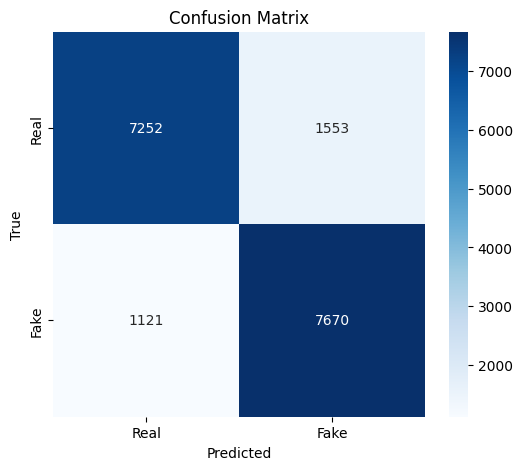

In [16]:
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="quantized_model.tflite")
interpreter.allocate_tensors()

# Get input and output details (for knowing which tensors to work with)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Define the directory for validation data
val_dir = "training_data/test"

# Load the validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=64,
    label_mode='binary'
)

# Apply normalization to the images
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Initialize lists to hold true labels and predicted labels
y_true = []
y_pred = []

# Loop through the validation dataset and perform inference
for images, labels in val_dataset:
    # Ensure that the images are of the correct shape (batch_size, height, width, channels)
    images = images.numpy().astype(np.float32)  # Convert to numpy array and float32
    
    # Loop over each image in the batch and run inference
    for i in range(images.shape[0]):
        # Get the image and add an extra batch dimension (1, height, width, channels)
        input_data = np.expand_dims(images[i], axis=0)  # Shape (1, 224, 224, 3)
        
        # Set the input tensor
        interpreter.set_tensor(input_details[0]['index'], input_data)
        
        # Run inference
        interpreter.invoke()
        
        # Get the output tensor
        output_data = interpreter.get_tensor(output_details[0]['index'])
        
        # Convert output to binary labels (0 or 1)
        y_pred_batch = (output_data > 0.5).astype(int)

        # Append true labels and predicted labels
        y_true.append(labels[i].numpy())
        y_pred.append(y_pred_batch[0][0])  # Extract the scalar value
        print(i)
# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate Precision, Recall, and F1 Score
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Print results
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}') 

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
